In [1]:
# include controllers to the path
import sys, os
sys.path.append(os.getcwd())
sys.path.append(os.path.join(os.getcwd(), 'controllers'))

# include pipeline repo to compute performance
sys.path.append(os.path.join(os.getcwd(), '..'))
sys.path.append(os.path.join(os.getcwd(), '..', 'pipeline'))
sys.path.append(os.path.join(os.getcwd(), '..', 'pipeline', 'postprocessing'))

import cv2
import threading
import math
import time
import random
import json
import datetime
import os, shutil
import numpy as np
import multiprocess as mp

# controllers
import nbimporter
from controllers.situtils import FPSTimes
from controllers.camera import WebcamStream
from controllers.video import VideoWriter
from controllers.microphones import MicrophoneController
from controllers.position_multimode import PositionTrackerSingle, PositionTrackerDouble
from controllers.sound import SoundController, ContinuousSoundStream
from controllers.serial import MCSArduino, FakeArduino, SpeakerMotor, CableMotor, APA102LEDStrip
from controllers.display import SITDisplay
from controllers.island import IslandFactory, Island
from controllers.temporal_trigger import TemporalTrigger
from controllers.temporal_trigger_mismatch import TemporalTriggerMismatchPlanner


from pplSIT.workflow.utils.pack import pack_base
from pplSIT.workflow.utils.performance import calculate_performance, plot_session_metrics, plot_performance
import h5py

## Load experiment settings

For every experimental cofiguration you can copy the original 'settings.json' file, build your own specific experimental preset, save it in this folder as e.g. 'settings_elena.json' and load it here instead of 'settings.json'.

In [2]:
# Andrey
# cfg_filename = os.path.join('profiles', '014393.json')
#cfg_filename = os.path.join('profiles', 'ppcSIT_013609_fd.json')
#cfg_filename = os.path.join('profiles', 'ppcSIT_013829_fd.json')  # no mark
#cfg_filename = os.path.join('profiles', 'ppcSIT_013830_fd.json')  # bold tail

# cfg_filename = os.path.join('profiles', 'mouse_freq.json')
# cfg_filename = os.path.join('profiles', 'implanted_multiSIT_660_1320.json')
# cfg_filename = os.path.join('profiles', 'implanted_timeSIT_25_50.json')
# cfg_filename = os.path.join('profiles', 'implanted_timeSIT_50_75.json')
# cfg_filename = os.path.join('profiles', 'implanted_timeSIT_12673.json')
# cfg_filename = os.path.join('profiles', 'implanted_timeSIT_25_50.json')
# cfg_filename = os.path.join('profiles', 'passive_FDA.json')
# cfg_filename = os.path.join('profiles', 'implanted_timeSIT_50_100.json')
#cfg_filename = os.path.join('profiles', 'implanted_timeSIT_50_52_5.json')
# cfg_filename = os.path.join('profiles', 'implanted_timeSIT_50_57_5.json')
# cfg_filename = os.path.join('profiles', 'timeSIT_50_55.json')
# cfg_filename = os.path.join('profiles', 'timeSIT_20_25.json')
# cfg_filename = os.path.join('profiles', 'timeSIT_20_275.json')
# cfg_filename = os.path.join('profiles', '015913_timeSIT_50_100.json')
# cfg_filename = os.path.join('profiles', '015913_freqSIT_660_1980.json')
# cfg_filename = os.path.join('profiles', '015913_timeSIT_50_100_freq_distractor.json')
# cfg_filename = os.path.join('profiles', '015913_freqSIT_660_1980_time_distractor.json')
# cfg_filename = os.path.join('profiles', '015913_light_freqSIT_dark_time_tt.json')
# cfg_filename = os.path.join('profiles', '015914_locSIT_tt.json')
# cfg_filename = os.path.join('profiles', '015914_locSIT.json')
cfg_filename = os.path.join('profiles', '017388_Miguel_highFreq_lowFreqdist.json')
#cfg_filename = os.path.join('profiles', 'habituation.json')
# cfg_filename = os.path.join('profiles', 'SITloc.json')
# gokce_timeSIT_90_108.json')

# cfg_filename = os.path.join('profiles', 'gokce_socialSIT.json')
# cfg_filename = os.path.join('profiles', 'miguel_chirp_newcode.json')
# cfg_filename = os.path.join('profiles', 'miguel_socialSIT_fireface.json')
# cfg_filename = os.path.join('profiles', 'miguel_socialSIT_fireface_chirp.json')

# cfg_filename = os.path.join('profiles', 'andrey_ppcSIT_SL_009266.json')

In [3]:
with open(os.path.join('profiles', 'default2.json')) as json_file:
    cfg = json.load(json_file)
with open(cfg_filename) as json_file:
    cfg_local = json.load(json_file)

for key in cfg.keys():
    if key in cfg_local: # only update if the key exists in the local config, otherwise keep default (important for backward compatibility with cfg files before microphones)
        cfg[key].update(cfg_local[key])
cfg['experiment']['experiment_date'] = datetime.datetime.now().strftime('%Y-%m-%d_%H-%M-%S')

# print loaded settings
#print(json.dumps(cfg, indent=4))

In [4]:
# check if the sound interface is there
import sounddevice as sd
asio = [x for x in sd.query_devices() if x['name'].find('ASIO') > 0]
#if len(asio) == 0:
#    raise SystemExit('The sound interface is not found. Please restart the computer')

In [5]:
sd.query_devices()

   0 Microsoft Sound Mapper - Input, MME (2 in, 0 out)
>  1 Analog (5+6) (RME Fireface UFX), MME (2 in, 0 out)
   2 Analog (1+2) (RME Fireface UFX), MME (2 in, 0 out)
   3 Analog (3+4) (RME Fireface UFX), MME (2 in, 0 out)
   4 Microsoft Sound Mapper - Output, MME (0 in, 2 out)
<  5 Speakers (RME Fireface UFX), MME (0 in, 2 out)
   6 Analog (5+6) (RME Fireface UFX), MME (0 in, 2 out)
   7 Analog (3+4) (RME Fireface UFX), MME (0 in, 2 out)
   8 Primary Sound Capture Driver, Windows DirectSound (2 in, 0 out)
   9 Analog (5+6) (RME Fireface UFX), Windows DirectSound (2 in, 0 out)
  10 Analog (1+2) (RME Fireface UFX), Windows DirectSound (2 in, 0 out)
  11 Analog (3+4) (RME Fireface UFX), Windows DirectSound (2 in, 0 out)
  12 Primary Sound Driver, Windows DirectSound (0 in, 2 out)
  13 Speakers (RME Fireface UFX), Windows DirectSound (0 in, 2 out)
  14 Analog (5+6) (RME Fireface UFX), Windows DirectSound (0 in, 2 out)
  15 Analog (3+4) (RME Fireface UFX), Windows DirectSound (0 in, 2 out)

In [6]:
asio

[{'name': 'Realtek ASIO',
  'hostapi': 2,
  'max_input_channels': 2,
  'max_output_channels': 2,
  'default_low_input_latency': 0.023219954648526078,
  'default_low_output_latency': 0.023219954648526078,
  'default_high_input_latency': 0.023219954648526078,
  'default_high_output_latency': 0.023219954648526078,
  'default_samplerate': 44100.0}]

## Initialize session folder

Run the upcoming cell, to create a session folder and to save the chosen experimetal parameters to a JSON-file ("experiment_id_parameters.json"). The session folder will be created here where this notebook is located.

In [7]:
# This session's protocols will be saved to this folder
cfg_exp = cfg['experiment']
experiment_id = "%s_%s_%s" % (cfg_exp['subject'], cfg_exp['experiment_type'], cfg_exp['experiment_date'])
save_to = os.path.join('sessions', experiment_id)
             
if not os.path.exists(save_to):
    os.makedirs(save_to)

# update paths (assuming this paths are relative to this notebook)
cfg['video']['file_path'] = os.path.join(save_to, cfg['video']['file_path'])
cfg['video']['csv_path'] = os.path.join(save_to, cfg['video']['csv_path'])
cfg['microphones']['file_path'] = os.path.join(save_to, cfg['microphones']['file_path'])
cfg['microphones']['csv_path'] = os.path.join(save_to, cfg['microphones']['csv_path'])
cfg['position']['file_path'] = os.path.join(save_to, cfg['position']['file_path'])
cfg['position']['contour_path'] = os.path.join(save_to, cfg['position']['contour_path'])
cfg['experiment']['file_path'] = os.path.join(save_to, cfg['experiment']['file_path'])
cfg['experiment']['islands_path'] = os.path.join(save_to, 'islands.csv')
if cfg['experiment'].get('temporal_trigger', False):
    cfg['experiment']['tt_islands_path'] = os.path.join(save_to, 'tt_islands.csv')
    with open(cfg['experiment']['tt_islands_path'], 'w') as f:
        f.write('isl_x, isl_y, isl_r, sound_id, time_trigger, time_elapsed, required_run_time, trial_no, mismatch_mode, expected_cue_type, led_cue_type, led_during_delay, sound_switch_enabled\n')
cfg['sound']['file_path'] = os.path.join(save_to, cfg['sound']['file_path'])
def resolve_asset_path(path):
    normalized = path.replace('\\', os.sep)
    if os.path.isabs(normalized):
        return normalized
    if normalized.startswith('assets' + os.sep) or normalized.startswith('assets/'):
        return normalized
    return os.path.join('assets', normalized)

cfg['position']['background_light'] = resolve_asset_path(cfg['position']['background_light'])
cfg['position']['background_dark'] = resolve_asset_path(cfg['position']['background_dark'])
if 'backgrounds_by_mode' in cfg['position']:
    cfg['position']['backgrounds_by_mode'] = {
        mode: resolve_asset_path(path) for mode, path in cfg['position']['backgrounds_by_mode'].items()
    }
if 'wav_file' in cfg['sound']:
    cfg['sound']['wav_file'] = resolve_asset_path(cfg['sound']['wav_file'])
if 'continuous' in cfg['sound']:
    cfg['sound']['continuous']['wav_file'] = resolve_asset_path(cfg['sound']['continuous']['wav_file'])
if 'cont_noise' in cfg['sound']:
    cfg['sound']['cont_noise']['filepath'] = resolve_asset_path(cfg['sound']['cont_noise']['filepath'])
    
# Saves all parameters to a JSON file with the user-defined "Experiment ID" as filename
with open(os.path.join(save_to, experiment_id + '.json'), 'w') as f:
    json.dump(cfg, f, indent=4)
    
with open(cfg['experiment']['file_path'], 'w') as f:
    # state: 0 - trial start, 1 - trial success, 2 - trial fail
    f.write('time, target_x, target_y, target_r, trial, state\n')

with open(cfg['experiment']['islands_path'], 'w') as f:
    f.write('tgt_x, tgt_y, tgt_r, d1_x, d1_y, d1_r, d2_x, d2_y, d2_r, d3_x, d3_y, d3_r\n')

In [8]:
def timeout(t_start):
    duration_total = cfg_exp['session_duration'] + cfg_exp['silence_before'] + cfg_exp['silence_after']
    return time.time() > t_start + duration_total if t_start is not None else False

In [9]:
def log_event(*args):  # log start / end of a trial
    with open(cfg_exp['file_path'], 'a') as f:
        f.write(",".join([str(x) for x in args]) + "\n")

In [10]:
def log_islands(islands):  # log position of the islands
    sorted_islands = sorted(islands, key=lambda x: x.sound_id, reverse=False)
    args = [(i.x, i.y, i.r) for i in sorted_islands]
    to_dump = [x for xs in args for x in xs]
        
    with open(cfg_exp['islands_path'], 'a') as f:    
        f.write(",".join([str(round(x, 4)) for x in to_dump]) + "\n")

In [11]:
def log_tt_islands(isl_x, isl_y, isl_r, sound_id, time_trigger, time_elapsed, required_run_time, trial_no, mismatch_plan=None):  # log position of the islands
    mismatch_fields = [
        TemporalTriggerMismatchPlanner.MATCHED,
        '',
        '',
        1,
        1,
    ]
    if mismatch_plan is not None:
        mismatch_fields = [
            mismatch_plan.mismatch_mode,
            mismatch_plan.expected_cue_type,
            mismatch_plan.led_cue_type,
            int(mismatch_plan.led_during_delay),
            int(mismatch_plan.sound_switch_enabled),
        ]
    to_dump = [isl_x, isl_y, isl_r, sound_id, time_trigger, time_elapsed, required_run_time, trial_no] + mismatch_fields

    with open(cfg_exp['tt_islands_path'], 'a') as f:
        f.write(",".join([str(x) for x in to_dump]) + "\n")

In [12]:
def switch_light(pt, board):
    pt.switch_background()
    board.switch_light()

## Start the experiment

This cell contains code for animal tracking. We hope that the comments provided in the code suffice to understand the individual steps and to adjust them to your own setup and needs, if necessary.

- press 's' to start recording
- press 's' again to stop recording
- press 'q' to quit

The experiment will stop automatically if the pre-defined session duration is reached.

In [13]:
cfg['sound']['cont_noise']

{'filepath': 'assets\\chirp_100ms_2000Hz_30000Hz.wav',
 'amp': 0.075,
 'channels': [5],
 'enabled': False}

In [14]:
# actual sound selector: -1 - noise, 0 - silence, 1 - foraging, 2 - target, 3 - distractor
sound = mp.Value('i', 1)
if 'noise_when_idle' in cfg_exp and cfg_exp['noise_when_idle']:
    sound.value = -1

# experiment status: 1 - idle, 2 - running (recording, logging), 0 - stopped
status = mp.Value('i', 1)

# init the sync with the acquisition system and feeder via Arduino
if cfg['experiment']['MCSArduinoPort'] == 'fake':
    board = FakeArduino()
else:
    board = MCSArduino(cfg['experiment']['MCSArduinoPort'])

# init speaker motor control
if 'motors_port' in cfg['experiment'] and cfg['experiment']['enable_motors']:
    motor_board = SpeakerMotor(cfg['experiment']['motors_port'])
    
# init ephys cable rotation motor
if 'cable_motor_port' in cfg['experiment']:
    cable_board = CableMotor(cfg['experiment']['cable_motor_port'])

# init APA102 LED strip (optional, for temporal trigger)
led_strip = None
led_current_color = None
if cfg_exp.get('apa102_enable', True) and 'apa102_port' in cfg_exp:
    led_strip = APA102LEDStrip(
        cfg_exp['apa102_port'],
        baud=cfg_exp.get('apa102_baud', 115200),
        command_format=cfg_exp.get('apa102_command_format', '{r},{g},{b}\n'),
        startup_sleep=cfg_exp.get('apa102_startup_sleep', 2.0),
        verbose=cfg_exp.get('apa102_verbose', True),
    )
    idle_color = cfg_exp.get('apa102_idle_color', [0, 0, 0])
    ack_idle = led_strip.set_color(*idle_color, read_ack=cfg_exp.get('apa102_read_ack', False))
    led_current_color = None  # force one sync in main loop
    if cfg_exp.get('apa102_self_test', True):
        test_color = cfg_exp.get('apa102_self_test_color', [255, 0, 0])
        ack_test = led_strip.set_color(*test_color, read_ack=cfg_exp.get('apa102_read_ack', False))
        time.sleep(cfg_exp.get('apa102_self_test_duration', 0.5))
        ack_back = led_strip.set_color(*idle_color, read_ack=cfg_exp.get('apa102_read_ack', False))
        led_current_color = None  # force one sync in main loop
        if cfg_exp.get('apa102_read_ack', False):
            print('APA102 self-test ACKs:', repr(ack_idle), repr(ack_test), repr(ack_back))
            if not (ack_test and ack_test.strip() == 'OK'):
                print('APA102: no valid ACK with current newline. Trying alternate command_format...')
                original_fmt = led_strip.command_format
                led_strip.command_format = '{r},{g},{b}\n' if original_fmt.endswith('\r\n') else '{r},{g},{b}\r\n'
                ack_test_alt = led_strip.set_color(*test_color, read_ack=True)
                time.sleep(0.3)
                led_strip.set_color(*idle_color, read_ack=False)
                led_current_color = None  # force one sync in main loop
                print('APA102 alt-format ACK:', repr(ack_test_alt), 'using format:', repr(led_strip.command_format))

print('Temporal trigger:', cfg_exp.get('temporal_trigger', False), 'APA102 enabled:', led_strip is not None)

# init continuous sound, if required
if 'continuous' in cfg['sound']:
    cst = ContinuousSoundStream(cfg['sound']['continuous'])
    cst.start()
    
# start the camera stream
vs = WebcamStream(cfg['camera'])
vs.start()

# init video recorders
vw  = VideoWriter(status, vs, cfg['video'])  # recorder with infos
vw.start()

cfg_video_raw = dict(cfg['video'])
cfg_video_raw['file_path']       = os.path.join(save_to, 'raw.avi')
cfg_video_raw['csv_path']        = os.path.join(save_to, 'raw.csv')
cfg_video_raw['frame_attr_name'] = 'frame_raw'
vwr = VideoWriter(status, vs, cfg_video_raw)  # recorder of raw video
vwr.start()

# init microphone controller, if required
if cfg['microphones']['record_audio']:
    mc = mp.Process(target=MicrophoneController.run, args=(status,cfg["microphones"]))
    mc.start()

# start position tracking
pt = PositionTrackerSingle(status, vs, cfg['position']) if cfg['position']['single_agent'] else PositionTrackerDouble(status, vs, cfg['position'])
pt.start()


# start temporal trigger, if required
tt = None
tt_mismatch = None
if cfg_exp.get('temporal_trigger', False):
    tt = TemporalTrigger(
        target_duration=cfg_exp['target_duration'],
        distractor_sound_ids=cfg_exp.get('distractor_sound_ids', []),
        distractor_probabilities=cfg_exp.get('distractor_probabilities', []),

        # new cumulative run-time gate + smoothing
        run_speed_threshold=cfg_exp.get('run_speed_threshold', 0.04),
        run_time_min=cfg_exp.get('run_time_min', 7.0),
        run_time_max=cfg_exp.get('run_time_max', 15.0),
        post_run_delay=cfg_exp.get('post_run_delay', 0.0),
        speed_eval_window=cfg_exp.get('speed_eval_window', 0.5),
        speed_hysteresis=cfg_exp.get('speed_hysteresis', 0.10),
    )
    tt_mismatch = TemporalTriggerMismatchPlanner(cfg_exp)
    

# playing sound in a separate process for performance
sound_commutator = SoundController.commutator
sc = mp.Process(target=SoundController.run, args=(sound, status, cfg['sound'], sound_commutator))
sc.start()

# print(pt.mask.shape)
# init frame renderer
dc = SITDisplay(pt, cfg['video'])
sounds_to_render = None
disp_s_island_prop = cfg['video']['display_sound_in_island']
if disp_s_island_prop:
    sounds_to_render = dict([(s_id, cfg['sound']['sounds'][s_str][disp_s_island_prop]) for s_id, s_str in sound_commutator.items() if 0 < s_id < 6])

cfg_pos = cfg['position']
isl_factory = IslandFactory(cfg_pos['floor_r_in_meters'], cfg_pos['angle_compensation'], cfg['experiment'])

timers = []
fps = FPSTimes()
names = ['camera', 'video', 'position', 'main']
distr_count = cfg['experiment']['distractor_islands']
trial = 0
rewards = 0
t_start = None
target_since = None
distractor_since = None
punishment_since = None
trial_start = time.time()
phase = 0  # 0 - idle, 1 - foraging, 2 - inter-trial interval
cfg_exp = cfg['experiment']
cfg_pos = cfg['position']
islands = []
iti_distance = 0.0
last_x, last_y = None, None

if cfg_exp.get('temporal_trigger', False):
    tt.reset()
    tt_mismatch.reset()
    # viol = False
    path_counter = 0.0
    trial_t0 = time.perf_counter()
    # seed last pos for distance gating
    last_tx, last_ty = pt.positions_in_m[0]
    tt_out = None

# initial position of the island, if set
#phi_initial = np.random.rand() * 2 * np.pi if cfg_exp['target_angle'] == 'random' else np.deg2rad(int(cfg_exp['target_angle']))
#rho = pt.cfg['floor_radius'] * pt.pixel_size - cfg_exp['target_radius']  # constant, in meters


# inaudible island trial profiles
max_trials = 200
p0 = np.array([0 for x in range(max_trials)])                          # never
p1 = np.array([0 if (x+1) % 4 > 0 else 1 for x in range(max_trials)])  # every 4-th trial
p2 = np.array([0 if (x+1) % 2 > 0 else 1 for x in range(max_trials)])  # every 2-nd trial
p3 = np.array([1 if x % 4 > 0 else 0 for x in range(max_trials)])      # always except every 4-th trial
unaudible_trials = np.vstack([p0, p1, p2, p3])

## TODO refactor a) trial init, b) trial failure and c) trial success as separate functions - read about state mgmt

trial_switch_lights = cfg_exp['trial_switch_lights']
apa102_debug = cfg_exp.get('apa102_debug', False)

def tracker_mode_name():
    return getattr(pt, 'tracking_mode', 'light' if pt.is_light else 'dark')

def led_color_for_mode(mode):
    if mode == 'iti':
        return cfg_exp.get('apa102_iti_color', [0, 0, 0])
    if mode == 'target':
        return cfg_exp.get('apa102_target_color', cfg_exp.get('apa102_window_color', [0, 0, 255]))
    if mode == 'distractor':
        return cfg_exp.get('apa102_distractor_color', [255, 0, 0])
    return cfg_exp.get('apa102_foraging_color', [0, 255, 0])

def reset_temporal_trigger_runtime(reset_trigger=True):
    global tt_out
    if tt is not None and reset_trigger:
        tt.reset()
    if tt_mismatch is not None:
        tt_mismatch.reset()
    tt_out = None

def resolve_temporal_sound(sound_id):
    if tt_mismatch is None:
        return sound_id
    return tt_mismatch.resolve_sound_id(sound_id, fallback_sound_id=1)

def temporal_mismatch_overlay_lines():
    if tt_mismatch is None or tt_mismatch.current is None:
        return ['TT mismatch: --']

    plan = tt_mismatch.current
    lines = [f"TT mismatch: {plan.mismatch_mode}"]
    if plan.mismatch_mode != TemporalTriggerMismatchPlanner.MATCHED:
        sound_mode = 'switch' if plan.sound_switch_enabled else 'hold'
        lines.append(f"TT cue: exp={plan.expected_cue_type} led={plan.led_cue_type} snd={sound_mode}")
    return lines

def sync_temporal_lighting(tt_state=None):
    plan = tt_mismatch.current if tt_mismatch is not None else None
    if tt_mismatch is not None:
        mode = tt_mismatch.resolve_led_mode(phase, tt_state, sound.value)
        led_color = led_color_for_mode(mode)
        if tt_state is not None and tt_state.get('pending_delay', False) and not tt_state.get('in_window', False) and plan is not None and apa102_debug:
            print(f"LED DELAY: mode={plan.mismatch_mode}, expected_sound_id={plan.expected_sound_id}, led_cue_type={plan.led_cue_type}, tracker_mode={mode}")
    else:
        if phase != 1:
            mode = 'iti'
        else:
            led_on = tt_state is not None and (tt_state.get('pending_delay', False) or tt_state.get('in_window', False))
            if led_on:
                current_sound_id = tt_state.get('sound_id', 2)
                mode = 'target' if current_sound_id == 2 else 'distractor'
                if tt_state is not None and tt_state.get('pending_delay', False) and not tt_state.get('in_window', False) and apa102_debug:
                    print(f"LED DELAY: sound_id={current_sound_id}, tracker_mode={mode}")
            else:
                mode = 'foraging'
        led_color = led_color_for_mode(mode)

    if hasattr(pt, 'set_tracking_mode'):
        pt.set_tracking_mode(mode)

    led_color = tuple(led_color)
    if led_strip is not None and led_current_color != led_color:
        led_strip.set_color(*led_color, read_ack=cfg_exp.get('apa102_read_ack', False))
        return led_color
    return led_current_color

if cfg_exp.get('temporal_trigger', False) and hasattr(pt, 'set_tracking_mode'):
    pt.set_tracking_mode('iti')

try:
    while trial <= cfg_exp['trial_number'] and not timeout(t_start):
        
        # ---------- rendering logic -----------
        frame = vs.read()
                
        if frame is None:
            time.sleep(0.1)
            continue # wait for the stream
            
        c_time = time.time()
        fps.count()
        angles, text_infos = [], []
        
        if not cfg_exp['target_angle'] == 'random':
            phi = isl_factory.phi_initial
            angles = [pt.correct_angle(phi), pt.correct_angle(phi) + np.deg2rad(cfg_exp['phi_max'])]
        
        for i, ctrl in enumerate([vs, vw, pt, fps]):  # FPS indicators
            text_infos.append('%s: %.2f FPS' % (names[i], ctrl.get_avg_fps()))
        
        potential_tgts = [i for i in islands if not i.is_distractor]
        if len(potential_tgts) > 0:
            target = [i for i in islands if not i.is_distractor][0]
            text_infos.append('Target: %.3f %.3f' % (target.x, target.y))
            
        text_infos.append('Time: %.2f' % float(c_time - t_start) if t_start is not None else 'Time: Idle')  # stopwatch
        text_infos.append('Trial: %.2f' % float(cfg_exp['trial_duration'] - (c_time - trial_start)) if phase == 1 else 'Trial: not started')
        text_infos.append('Trial: %s' % trial)
        text_infos.append('Rewards: %s' % rewards)  # rewards
        text_infos.append('In target: %.2f' % float(c_time - target_since) if target_since is not None else 'In target: --')
        if cfg_exp.get('distractor_islands', 0)>0:
            text_infos.append('In distractor: %.2f' % float(c_time - distractor_since) if distractor_since is not None else 'In distractor: --')
        text_infos.append('ITI distance: %.2f' % iti_distance if iti_distance > 0 else 'ITI distance: --')
        if cfg_exp.get('temporal_trigger', False):
            text_infos.append('Time running: %.2f' % tt_out['time_above_thr'] if tt_out is not None and phase == 1 else 'Time running: --')
            text_infos.append('Run time required: %.2f' % tt_out['required_run_time'] if tt_out is not None and phase == 1 else 'Run time required: --')
            text_infos.extend(temporal_mismatch_overlay_lines())
        text_infos.append('Tracking mode: %s' % tracker_mode_name())

        vs.frame_raw = frame  # save raw frame
        frame, frame_to_save = dc.render(frame, status, islands=islands, angles=angles, text_infos=text_infos, sounds_to_render=sounds_to_render)
            
        # assign the frame back to the video stream for other controllers
        vs.frame_with_infos = frame_to_save
        
        cv2.imshow('Press (s)-to start/stop, (q)-to end', frame)

        # keep tracker/APA102 state in sync during ITI and idle
        if cfg_exp.get('temporal_trigger', False) and phase != 1:
            led_current_color = sync_temporal_lighting(tt_out)
        elif led_strip is not None and phase != 1:
            iti_color = tuple(cfg_exp.get('apa102_iti_color', [0, 0, 0]))
            if led_current_color != iti_color:
                led_strip.set_color(*iti_color, read_ack=cfg_exp.get('apa102_read_ack', False))
                led_current_color = iti_color

        # -------- experiment logic ---------------
        
        # animals is either foraging (phase == 1) or in the inter-trial-interval (phase == 2)
        if phase == 1: # foraging
            if pt.positions_in_m is not None and (len(islands) > 0 or cfg_exp.get('temporal_trigger', False)):
                if cfg_exp.get('temporal_trigger', False):
                    # compute distance since last tracker sample
                    cx, cy = pt.positions_in_m[0]
                    new_sample = (cx != last_tx) or (cy != last_ty)   # if you have a frame/timestamp index, use that instead
                    if new_sample:
                        dist = ((cx - last_tx)**2 + (cy - last_ty)**2) ** 0.5
                        last_tx, last_ty = cx, cy
                    else:
                        dist = 0.0

                    t_elapsed = time.perf_counter() - trial_t0
                    tt_out = tt.update(t_elapsed, dist, new_sample=new_sample)

                    if tt_mismatch is not None and tt_out['sound_id'] is not None and (tt_out.get('just_armed_delay', False) or ((tt_out.get('pending_delay', False) or tt_out.get('in_window', False)) and tt_mismatch.current is None)):
                        tt_plan = tt_mismatch.ensure_plan(tt_out['sound_id'])
                        if apa102_debug:
                            print(f"TT mismatch plan: mode={tt_plan.mismatch_mode}, expected_sound_id={tt_plan.expected_sound_id}, led_cue_type={tt_plan.led_cue_type}, sound_switch_enabled={tt_plan.sound_switch_enabled}")
                    else:
                        tt_plan = tt_mismatch.current if tt_mismatch is not None else None

                    if tt_out['in_window'] and tt_out['just_started']:
                        islands = [Island(cx,cy,cfg_exp['target_radius'], tt_out['sound_id'], False if tt_out['sound_id']==2 else True)]
                        # TODO log island and current time
                        log_tt_islands(cx,cy,cfg_exp['target_radius'], tt_out['sound_id'], c_time, t_elapsed, tt_out['required_run_time'], trial, mismatch_plan=tt_plan)
                        if apa102_debug:
                            print('created a new island')
                    led_current_color = sync_temporal_lighting(tt_out)
                    if not tt_out['pending_delay'] and not tt_out['in_window']:
                        islands = []
                        if tt_mismatch is not None:
                            tt_mismatch.reset()
                        


                
                potential_tgts = [i for i in islands if not i.is_distractor]
                if len(potential_tgts) > 0:
                    tgt = [i for i in islands if not i.is_distractor][0]
                else:
                    tgt = None
                distractors = [i for i in islands if i.is_distractor]
                if len(distractors)>1:
                    if apa102_debug:
                        print(distractors)
                # check if animal in the island and for how long
                if tgt is None:
                    inside_tgt_condition = False
                else:
                    inside_tgt_condition = pt.is_inside(tgt.x, tgt.y, cfg_exp['target_radius'])
                    
                if inside_tgt_condition:
                    if target_since is None:  # just entered target
                        target_since = c_time
                        if unaudible_trials[cfg_exp['unaudible_profile']][trial - 1] == 0:
                            sound.value = resolve_temporal_sound(2)

                    elif (c_time - target_since > cfg_exp['target_duration']) and ((cfg_exp['light_cued_task'] and pt.is_light) or not cfg_exp['light_cued_task']): # successful trial
                        # log trial success
                        if tgt is None:
                            log_event(c_time, round(-1, 4), round(-1, 4), round(-1, 4), trial, 1)
                        else:
                            log_event(c_time, round(tgt.x, 4), round(tgt.y, 4), round(tgt.r, 4), trial, 1) 
                        tf = threading.Timer(0, board.feed, args=[cfg_exp['n_pellets']])
                        tf.start()

                        # init inter-trial interval and new trial
                        trial_start = c_time + cfg_exp['iti_duration'] + 5 * np.random.rand()  # random b/w 20-25 sec
                        sound.value = 0  # silence
                        islands = []
                        phase = 2
                        if cfg_exp.get('temporal_trigger', False):
                            reset_temporal_trigger_runtime()
                        rewards += 1
                        target_since = None
                    elif (c_time - target_since > cfg_exp['target_duration']) and (cfg_exp['light_cued_task'] and not pt.is_light): # fail because it's dark
                        if tgt is None:
                            log_event(c_time, round(-1, 4), round(-1, 4), round(-1, 4), trial, 2)
                        else:
                            log_event(c_time, round(tgt.x, 4), round(tgt.y, 4), round(tgt.r, 4), trial, 2) # log trial failed
                        trial_start = c_time + cfg_exp['iti_duration'] + 5 * np.random.rand()  # random b/w 10-15 sec
                        sound.value = -1  # punishment
                        punishment_since = c_time
                        islands = []
                        phase = 2
                        if cfg_exp.get('temporal_trigger', False):
                            reset_temporal_trigger_runtime()
                        target_since = None
                        
                elif c_time - trial_start > cfg_exp['trial_duration']:  # trial failed and animal is not in the target
                    ## TODO refactor this + trial fail below into a function
                    # log trial failed because of time
                    if tgt is None:
                        log_event(c_time, round(-1, 4), round(-1, 4), round(-1, 4), trial, 2)
                    else:
                        log_event(c_time, round(tgt.x, 4), round(tgt.y, 4), round(tgt.r, 4), trial, 2) 
                    
                    trial_start = c_time + cfg_exp['iti_duration'] + 5 * np.random.rand()  # random b/w 10-15 sec
                    sound.value = -1  # punishment
                    punishment_since = c_time
                    islands = []
                    phase = 2
                    if cfg_exp.get('temporal_trigger', False):
                        reset_temporal_trigger_runtime()
                    distractor_since = None
                    target_since = None # take care of the case in which animal was in target at trial end but exited before target_duration
                
                else:
                    target_since = None
                    in_distractor = False
                    
                    for isl in distractors:  # maybe animal is in one of the distractors
                        if pt.is_inside(isl.x, isl.y, cfg_exp['target_radius']):
                            if distractor_since is None:  # just entered distractor
                                distractor_since = c_time
                                
                            sound.value = resolve_temporal_sound(isl.sound_id)
                            in_distractor = True
                            
                            if c_time - distractor_since > cfg_exp['target_duration'] and cfg_exp['distractor_fail'] and ((cfg_exp['light_cued_task'] and pt.is_light) or not cfg_exp['light_cued_task']):
                                # fail trial because in distractor
                                if tgt is None:
                                    log_event(c_time, round(-1, 4), round(-1, 4), round(-1, 4), trial, 2)
                                else:
                                    log_event(c_time, round(tgt.x, 4), round(tgt.y, 4), round(tgt.r, 4), trial, 2) # log trial failed
                                trial_start = c_time + cfg_exp['iti_duration'] + 5 * np.random.rand()  # random b/w 10-15 sec
                                sound.value = -1  # punishment
                                punishment_since = c_time
                                islands = []
                                phase = 2
                                if cfg_exp.get('temporal_trigger', False):
                                    reset_temporal_trigger_runtime()
                                distractor_since = None
                            elif c_time - distractor_since > cfg_exp['target_duration'] and cfg_exp['distractor_fail'] and (cfg_exp['light_cued_task'] and not pt.is_light):
                                if tgt is None:
                                    log_event(c_time, round(-1, 4), round(-1, 4), round(-1, 4), trial, 1)
                                else:
                                    log_event(c_time, round(tgt.x, 4), round(tgt.y, 4), round(tgt.r, 4), trial, 1) # log trial success
                                tf = threading.Timer(0, board.feed, args=[cfg_exp['n_pellets']])
                                tf.start()
                                
                                # init inter-trial interval and new trial
                                trial_start = c_time + cfg_exp['iti_duration'] + 5 * np.random.rand()  # random b/w 20-25 sec
                                sound.value = 0  # silence
                                islands = []
                                phase = 2
                                if cfg_exp.get('temporal_trigger', False):
                                    reset_temporal_trigger_runtime()
                                rewards += 1
                                distractor_since = None
                                
                        else:
                            distractor_since = None
                    
                    if not in_distractor:  # outside of the islands
                        sound.value = 1

                        if cfg_exp.get('temporal_trigger', False):
                            if tt_out is not None and tt_out['in_window']:
                                # viol = True
                                reset_temporal_trigger_runtime()

                if cfg_exp.get('temporal_trigger', False):
                    led_current_color = sync_temporal_lighting(tt_out)
            
        elif phase == 2:  # inter-trial-interval
            # count distance between trials
            if last_x is None:
                last_x, last_y = pt.positions_in_m[0]
            else:
                x, y = pt.positions_in_m[0]
                iti_distance += np.sqrt((x - last_x)**2 + (y - last_y)**2)
                last_x, last_y = x, y
            
            # reset punishment sound
            if punishment_since is not None and c_time - punishment_since > cfg_exp['punishment_duration']:
                sound.value = 0
                punishment_since = None

            # animal is not inside the island
            if isl_factory.last_tgt_x is not None:
                is_inside_island = pt.is_inside(isl_factory.last_tgt_x, isl_factory.last_tgt_y, cfg_exp['target_radius'])
            else:
                is_inside_island = False

            # silence after the recording
            in_silence = c_time < t_start + cfg_exp['silence_before'] or\
                c_time > t_start + cfg_exp['silence_before'] + cfg_exp['session_duration']
            
            # enough time in ITI
            # animal is not sitting in ITI
            # not yet silence period after
            if c_time > trial_start and iti_distance > cfg_exp['iti_distance'] and not is_inside_island and not in_silence:
                ## TODO refactor this + trial init below into a function
                # init_new_trial
                if cfg_exp.get('temporal_trigger', False):
                    islands = []
                else:
                    islands = isl_factory.generate_islands(c_time - t_start)
                    log_islands(islands)  # log island(s) positions
                sound.value = 1
                phase = 1
                trial += 1
                
                if trial in trial_switch_lights:
                    switch_light(pt, board)
                    trial_switch_lights.remove(trial)
                
                # reset ITI distance and trial_start
                iti_distance = 0
                trial_start = c_time

                if cfg_exp.get('temporal_trigger', False):
                    reset_temporal_trigger_runtime()
                    # viol = False
                    path_counter = 0.0
                    trial_t0 = time.perf_counter()
                    # seed last pos for distance gating
                    last_tx, last_ty = pt.positions_in_m[0]
                    islands = []
                
                # log trial start
                potential_tgts = [i for i in islands if not i.is_distractor]
                if len(potential_tgts) > 0:
                    tgt = [i for i in islands if not i.is_distractor][0]
                else:
                    tgt = None
                if tgt is None:
                    log_event(c_time, round(-1, 4), round(-1, 4), round(-1, 4), trial, 0)
                else:
                    log_event(c_time, round(tgt.x, 4), round(tgt.y, 4), round(tgt.r, 4), trial, 0)
        
        # -------- key press events ---------------
        
        k = cv2.waitKey(10)
        
        # light on/off
        if k == ord('l'):
            switch_light(pt, board)
        
        # motors
        if k == ord('d'):
            if cfg['experiment']['enable_motors']:
                motor_board.switch_diodes()
         
        # disable motor control for safety
        #if k == ord('t'):
        #    tm = threading.Timer(20, motor_board.rotate, args=(False, 90, 30))
        #    tm.start()
        #    #motor_board.rotate(False, 90, 30)
        #if k == ord('r'):
        #    tm = threading.Timer(20, motor_board.rotate, args=(True, 90, 30))
        #    tm.start()
        
        # ephys cable on top
        if k == ord('i') and 'cable_motor_port' in cfg['experiment']:
            tf = threading.Timer(0, cable_board.turn_CCW, args=[])
            tf.start()
        if k == ord('o') and 'cable_motor_port' in cfg['experiment']:
            tf = threading.Timer(0, cable_board.turn_CW, args=[])
            tf.start()
            
        # feeding
        if k == ord('f'):
            tf = threading.Timer(0, board.feed, args=[])
            tf.start()

        if k == ord('c'):
            capture_mode = tracker_mode_name() if cfg_exp.get('temporal_trigger', False) else ('light' if pt.is_light else 'dark')
            if hasattr(pt, 'save_background'):
                f_name = pt.save_background(dc.masked_frame, mode=capture_mode, reload_after=False)
            else:
                f_name = cfg_pos['background_light'] if pt.is_light else cfg_pos['background_dark']
                cv2.imwrite(f_name, dc.masked_frame)
            print('Saved background for %s to %s' % (capture_mode, f_name))
            tf = threading.Timer(0.2, pt.reload_background, args=[cfg_pos])
            tf.start()            

        # quit the session
        if k == ord('q'):
            break

        # start the experiment
        if k == ord('s'):
            board.start_or_stop()  # start/stop data acquisition
            c_time = time.time()   # more accurate time
            
            if cfg['experiment']['enable_motors']:
                if not motor_board.diodes_on:
                    motor_board.switch_diodes()

            if status.value == 1: # start the session
                if t_start is None:
                    t_start = c_time
                trial_start = c_time + cfg_exp['silence_before']
                status.value = 2

                # init_new_trial
                if cfg_exp['silence_before'] == 0:
                    if cfg_exp.get('temporal_trigger', False):
                        islands = []
                    else:
                        islands = isl_factory.generate_islands(c_time - t_start)
                        log_islands(islands)  # log island(s) positions
                    sound.value = 1
                    phase = 1
                    trial += 1
                    if trial in trial_switch_lights:
                        switch_light(pt, board)
                        trial_switch_lights.remove(trial)
                    # log trial start
                    potential_tgts = [i for i in islands if not i.is_distractor]
                    if len(potential_tgts) > 0:
                        tgt = [i for i in islands if not i.is_distractor][0]
                    else:
                        tgt = None
                    
                    if tgt is None:
                        log_event(c_time, round(-1, 4), round(-1, 4), round(-1, 4), trial, 0)
                    else:
                        log_event(c_time, round(tgt.x, 4), round(tgt.y, 4), round(tgt.r, 4), trial, 0)
                    
                else:  # or start with ITI to record in silence before
                    sound.value = 0
                    phase = 2
                    
                # init light events
                timers = []
                for event_t in cfg_exp['light_events']:
                    timers.append(threading.Timer(event_t, switch_light, args=(pt, board)))
                    
                if cfg['experiment']['enable_motors']:
                    if not cfg['experiment']['phi_max'] == 0 and len(cfg['experiment']['timepoints']) > 0:
                        direction = False if cfg['experiment']['phi_max'] > 0 else True
                        t0, t1 = cfg['experiment']['timepoints'][0], cfg['experiment']['timepoints'][1]
                        timers.append(threading.Timer(t0, motor_board.rotate, args=(direction, abs(cfg['experiment']['phi_max']), t1-t0)))
                        t0, t1 = cfg['experiment']['timepoints'][2], cfg['experiment']['timepoints'][3]
                        timers.append(threading.Timer(t0, motor_board.rotate, args=(not direction, abs(cfg['experiment']['phi_max']), t1-t0)))
                    
                for t in timers:
                    t.start()
                
            elif status.value == 2:  # pause the session
                if len(islands) > 0:
                    tgt = [i for i in islands if not i.is_distractor][0]
                    x, y, r = round(tgt.x, 4), round(tgt.y, 4), round(tgt.r, 4)
                else:
                    x, y, r = 0, 0, 0
                log_event(c_time, x, y, r, trial, -1)  # log experiment break
                
                if 'noise_when_idle' in cfg_exp and cfg_exp['noise_when_idle']:
                    sound.value = -1
                status.value = 1
                phase = 0
                if cfg_exp.get('temporal_trigger', False):
                    reset_temporal_trigger_runtime()
                islands = []
                for t in timers:
                    t.cancel()
                    
        if k == ord('a'):
            sound.value = -1 if sound.value >= 0 else 0
            switch_light(pt, board)  # turn lights off 

finally:
    if status.value == 2:  # stop data acquisition, in case exited via timeout
        board.start_or_stop()
        if len(islands) > 0:
            tgt = [i for i in islands if not i.is_distractor][0]
            x, y, r = round(tgt.x, 4), round(tgt.y, 4), round(tgt.r, 4)
        else:  
            x, y, r = 0, 0, 0
        log_event(c_time, x, y, r, trial, -1)  # log experiment end
        
    status.value = 0
    time.sleep(0.01)
    for t in timers:
        t.cancel()
    
    if board.is_light_off:
        board.switch_light()  # turn light back on
        time.sleep(0.1)
    board.exit()
    
    if cfg['experiment']['enable_motors']:
        if motor_board.diodes_on:
            motor_board.switch_diodes()
        motor_board.exit()
    if 'cable_motor_port' in cfg['experiment']:
        cable_board.exit()
    if led_strip is not None:
        led_strip.exit()
    
    cv2.destroyAllWindows()
    sc.join()
    for ctrl in [pt, vw, vwr, vs]:
        ctrl.stop()

    # stop microphones recording process
    if cfg['microphones']['record_audio']:
        mc.join()

    if 'continuous' in cfg['sound']:
        time.sleep(cfg['sound']['continuous']['end_sleep'])
        cst.stop()

Temporal trigger: False APA102 enabled: False
Webcam stream 1024.0:768.0 at 30.00 FPS started
Position tracker stopped
Video writer stopped
Video writer stopped
Camera released


### Merge data in HDF5 file

In [15]:
h5name = os.path.join(save_to, experiment_id + '.h5')
pack_base(
    cfg['position']['file_path'],
    cfg['experiment']['file_path'],
    cfg['sound']['file_path'],
    cfg['experiment']['islands_path'],
    os.path.join(save_to, experiment_id + '.json'),
    os.path.join('assets','manual.json'),
    h5name
)

### Plot sessions stats

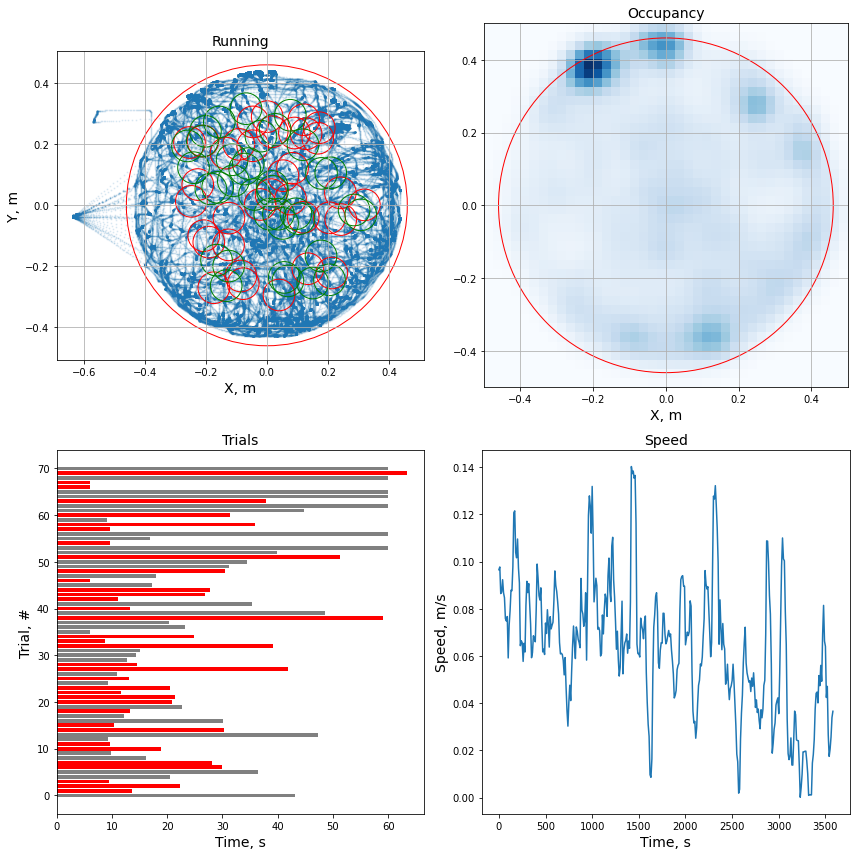

In [16]:
with h5py.File(h5name, 'r') as f:
    tl = np.array(f['processed']['timeline'])
    trial_idxs = np.array(f['processed']['trial_idxs'])
    islands = np.array(f['raw']['islands'])

plot_session_metrics(tl, trial_idxs, cfg, None)

## Performance

In [17]:
perf = calculate_performance(tl, trial_idxs, cfg, islands=islands)
plot_performance(cfg, perf, None)

TypeError: 'Island' object is not subscriptable